In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DRIVE_ROOT   = '/content/drive/MyDrive/rice-pest-cnn'
DATASET_DIR  = f'{DRIVE_ROOT}/dataset'          # source images, one folder per class
MODEL_DIR    = f'{DRIVE_ROOT}/model'
SPLIT_DIR    = '/content/rice_pest_data'        # local, fast disk for training
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
NUM_CLASSES = len(CLASSES)
print(f"Found {NUM_CLASSES} classes:")
for c in CLASSES:
    print(f"  - {c}")

WEAK_CLASSES = {'golden_apple_snail'}
BASE_TARGET_PER_CLASS = 1000
WEAK_TARGET_PER_CLASS = 1400

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

Mounted at /content/drive
Found 10 classes:
  - army_worm
  - brown_plant_hopper
  - golden_apple_snail
  - green_leafhopper
  - no_pest
  - paddy_stem_maggot
  - rice_black_bug
  - rice_bugs
  - rice_leaf_caterpillar
  - rice_stem_borer(adult)

Using device: cuda


In [2]:
def split_already_done():
    for split in ('train', 'val', 'test'):
        for cls in CLASSES:
            p = os.path.join(SPLIT_DIR, split, cls)
            if not os.path.isdir(p) or len(os.listdir(p)) == 0:
                return False
    return True

if split_already_done():
    print("Split already exists in", SPLIT_DIR, "— skipping.")
else:
    import shutil
    SPLIT_RATIOS = {'train': 0.70, 'val': 0.15, 'test': 0.15}
    print("Splitting dataset...\n")
    for cls in CLASSES:
        images = [f for f in os.listdir(os.path.join(DATASET_DIR, cls)) if f.lower().endswith('.jpg')]
        random.shuffle(images)
        n = len(images)
        n_train = int(n * SPLIT_RATIOS['train'])
        n_val   = int(n * SPLIT_RATIOS['val'])
        parts = {
            'train': images[:n_train],
            'val':   images[n_train:n_train + n_val],
            'test':  images[n_train + n_val:],
        }
        for split, files in parts.items():
            dest = os.path.join(SPLIT_DIR, split, cls)
            os.makedirs(dest, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(DATASET_DIR, cls, f), os.path.join(dest, f))

print("\nCurrent split sizes:")
for split in ('train', 'val', 'test'):
    print(f"--- {split} ---")
    for cls in CLASSES:
        print(f"  {cls}: {len(os.listdir(os.path.join(SPLIT_DIR, split, cls)))}")

Splitting dataset...


Current split sizes:
--- train ---
  army_worm: 359
  brown_plant_hopper: 487
  golden_apple_snail: 396
  green_leafhopper: 586
  no_pest: 310
  paddy_stem_maggot: 410
  rice_black_bug: 663
  rice_bugs: 496
  rice_leaf_caterpillar: 438
  rice_stem_borer(adult): 491
--- val ---
  army_worm: 77
  brown_plant_hopper: 104
  golden_apple_snail: 84
  green_leafhopper: 125
  no_pest: 66
  paddy_stem_maggot: 87
  rice_black_bug: 142
  rice_bugs: 106
  rice_leaf_caterpillar: 93
  rice_stem_borer(adult): 105
--- test ---
  army_worm: 78
  brown_plant_hopper: 106
  golden_apple_snail: 86
  green_leafhopper: 127
  no_pest: 68
  paddy_stem_maggot: 89
  rice_black_bug: 143
  rice_bugs: 107
  rice_leaf_caterpillar: 95
  rice_stem_borer(adult): 106


In [3]:
from PIL import Image, ImageEnhance, ImageOps

def augment_image(img):
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    img = img.rotate(random.uniform(-25, 25), expand=False)
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))
    return img

train_dir = os.path.join(SPLIT_DIR, 'train')

for cls in CLASSES:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith('.jpg')]
    real_images = [f for f in images if not f.startswith('aug_')]
    target = WEAK_TARGET_PER_CLASS if cls in WEAK_CLASSES else BASE_TARGET_PER_CLASS
    current = len(images)

    if current >= target:
        print(f"{cls}: {current} images (target {target}) — skipping")
        continue

    needed = target - current
    print(f"{cls}: {current} images — generating {needed} more (target {target})...")
    for i in range(needed):
        src = random.choice(real_images)
        img = Image.open(os.path.join(cls_path, src)).convert('RGB')
        aug_img = augment_image(img)
        aug_img.save(os.path.join(cls_path, f"aug_{current + i:05d}.jpg"), quality=90)

print("\nFinal train counts:")
for cls in CLASSES:
    print(f"  {cls}: {len(os.listdir(os.path.join(train_dir, cls)))}")

army_worm: 359 images — generating 641 more (target 1000)...
brown_plant_hopper: 487 images — generating 513 more (target 1000)...
golden_apple_snail: 396 images — generating 1004 more (target 1400)...
green_leafhopper: 586 images — generating 414 more (target 1000)...
no_pest: 310 images — generating 690 more (target 1000)...
paddy_stem_maggot: 410 images — generating 590 more (target 1000)...
rice_black_bug: 663 images — generating 337 more (target 1000)...
rice_bugs: 496 images — generating 504 more (target 1000)...
rice_leaf_caterpillar: 438 images — generating 562 more (target 1000)...
rice_stem_borer(adult): 491 images — generating 509 more (target 1000)...

Final train counts:
  army_worm: 1000
  brown_plant_hopper: 1000
  golden_apple_snail: 1400
  green_leafhopper: 1000
  no_pest: 1000
  paddy_stem_maggot: 1000
  rice_black_bug: 1000
  rice_bugs: 1000
  rice_leaf_caterpillar: 1000
  rice_stem_borer(adult): 1000


In [4]:
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'val'),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'test'),  transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = [c for c, _ in sorted(train_dataset.class_to_idx.items(), key=lambda kv: kv[1])]
print("Class mapping:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {idx}: {name}")

real_counts = {
    cls: len([f for f in os.listdir(os.path.join(DATASET_DIR, cls)) if f.lower().endswith('.jpg')])
    for cls in CLASSES
}
total_real = sum(real_counts.values())
class_weights = torch.tensor(
    [total_real / (NUM_CLASSES * real_counts[c]) for c in CLASS_NAMES],
    dtype=torch.float32,
).to(device)
print("\nClass weights (higher = rarer in the original dataset):")
for name, w in zip(CLASS_NAMES, class_weights.tolist()):
    print(f"  {name}: {w:.2f}")

Class mapping:
  0: army_worm
  1: brown_plant_hopper
  2: golden_apple_snail
  3: green_leafhopper
  4: no_pest
  5: paddy_stem_maggot
  6: rice_black_bug
  7: rice_bugs
  8: rice_leaf_caterpillar
  9: rice_stem_borer(adult)

Class weights (higher = rarer in the original dataset):
  army_worm: 1.29
  brown_plant_hopper: 0.95
  golden_apple_snail: 1.17
  green_leafhopper: 0.79
  no_pest: 1.49
  paddy_stem_maggot: 1.13
  rice_black_bug: 0.70
  rice_bugs: 0.94
  rice_leaf_caterpillar: 1.06
  rice_stem_borer(adult): 0.94


In [5]:
model = models.mobilenet_v3_large(weights='IMAGENET1K_V1')

# Freeze the whole backbone to start
for p in model.features.parameters():
    p.requires_grad = False

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES),
)
model = model.to(device)
print("Model ready. Trainable params (phase 1):",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 142MB/s]


Model ready. Trainable params (phase 1): 1242890


In [6]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
import copy

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
best_model_path = '/content/best_model.pth'

def run_epoch(loader, train, scaler=None):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
                with autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, 100.0 * correct / total

def train_phase(epochs, lr, patience, phase_name):
    global optimizer, scheduler
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()

    best_val_acc = 0.0
    best_state = None
    no_improve = 0
    history = []

    print(f"\n=== {phase_name}: {epochs} epochs max, lr={lr}, patience={patience} ===")
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(train_loader, train=True, scaler=scaler)
        val_loss, val_acc = run_epoch(val_loader, train=False)
        scheduler.step()
        history.append((train_loss, train_acc, val_loss, val_acc))

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        print(f"Epoch {epoch:2d}/{epochs} | train loss {train_loss:.3f} acc {train_acc:.1f}% | "
              f"val loss {val_loss:.3f} acc {val_acc:.1f}% {'✓ best' if improved else ''}")

        if no_improve >= patience:
            print(f"No improvement for {patience} epochs — stopping {phase_name} early.")
            break

    model.load_state_dict(best_state)
    return best_val_acc, history

# Phase 1: train the head only
phase1_best_acc, phase1_history = train_phase(epochs=15, lr=1e-3, patience=5, phase_name="Phase 1 (head only)")

# Phase 2: unfreeze last blocks, fine-tune at lower LR
for name, p in model.features.named_parameters():
    block_idx = name.split('.')[0]
    if block_idx.isdigit() and int(block_idx) >= len(model.features) - 4:
        p.requires_grad = True

print("\nTrainable params (phase 2):", sum(p.numel() for p in model.parameters() if p.requires_grad))
phase2_best_acc, phase2_history = train_phase(epochs=25, lr=1e-4, patience=7, phase_name="Phase 2 (fine-tune)")

best_val_acc = max(phase1_best_acc, phase2_best_acc)
torch.save(model.state_dict(), best_model_path)
print(f"\nBest overall validation accuracy: {best_val_acc:.2f}%")
print(f"Best weights saved to: {best_model_path}")


=== Phase 1 (head only): 15 epochs max, lr=0.001, patience=5 ===


/tmp/ipykernel_2979/533231914.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_2979/533231914.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  1/15 | train loss 0.982 acc 81.3% | val loss 0.843 acc 90.3% ✓ best
Epoch  2/15 | train loss 0.784 acc 90.3% | val loss 0.806 acc 91.5% ✓ best
Epoch  3/15 | train loss 0.716 acc 93.7% | val loss 0.770 acc 92.2% ✓ best
Epoch  4/15 | train loss 0.678 acc 95.5% | val loss 0.756 acc 93.5% ✓ best
Epoch  5/15 | train loss 0.659 acc 96.4% | val loss 0.742 acc 93.9% ✓ best
Epoch  6/15 | train loss 0.637 acc 97.1% | val loss 0.735 acc 94.3% ✓ best
Epoch  7/15 | train loss 0.621 acc 97.8% | val loss 0.725 acc 93.9% 
Epoch  8/15 | train loss 0.603 acc 98.4% | val loss 0.717 acc 94.3% 
Epoch  9/15 | train loss 0.597 acc 98.7% | val loss 0.714 acc 94.6% ✓ best
Epoch 10/15 | train loss 0.589 acc 98.9% | val loss 0.707 acc 94.8% ✓ best
Epoch 11/15 | train loss 0.582 acc 99.0% | val loss 0.702 acc 94.8% 
Epoch 12/15 | train loss 0.577 acc 99.1% | val loss 0.705 acc 94.5% 
Epoch 13/15 | train loss 0.573 acc 99.3% | val loss 0.702 acc 95.0% ✓ best
Epoch 14/15 | train loss 0.570 acc 99.3% | val lo

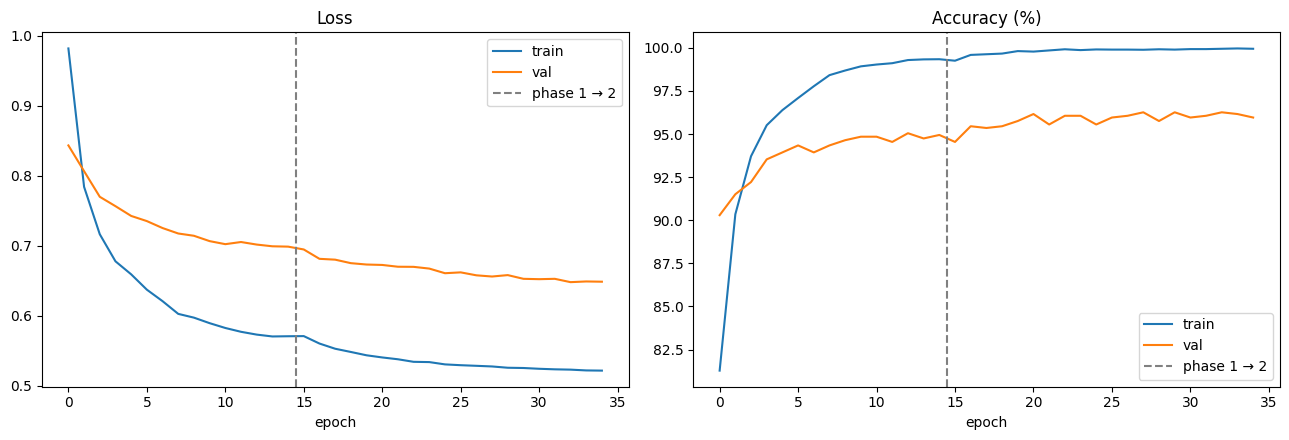

In [7]:
import matplotlib.pyplot as plt

full_history = phase1_history + phase2_history
train_losses, train_accs, val_losses, val_accs = zip(*full_history)
phase1_len = len(phase1_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(train_losses, label='train'); axes[0].plot(val_losses, label='val')
axes[0].axvline(phase1_len - 0.5, color='gray', linestyle='--', label='phase 1 → 2')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(train_accs, label='train'); axes[1].plot(val_accs, label='val')
axes[1].axvline(phase1_len - 0.5, color='gray', linestyle='--', label='phase 1 → 2')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

FINAL TEST RESULTS
                        precision    recall  f1-score   support

             army_worm     0.9481    0.9359    0.9419        78
    brown_plant_hopper     0.9406    0.8962    0.9179       106
    golden_apple_snail     0.9885    1.0000    0.9942        86
      green_leafhopper     0.9286    0.9213    0.9249       127
               no_pest     0.9189    1.0000    0.9577        68
     paddy_stem_maggot     0.9753    0.8876    0.9294        89
        rice_black_bug     1.0000    0.9860    0.9930       143
             rice_bugs     0.9640    1.0000    0.9817       107
 rice_leaf_caterpillar     0.8900    0.9368    0.9128        95
rice_stem_borer(adult)     0.9907    1.0000    0.9953       106

              accuracy                         0.9562      1005
             macro avg     0.9545    0.9564    0.9549      1005
          weighted avg     0.9568    0.9562    0.9560      1005



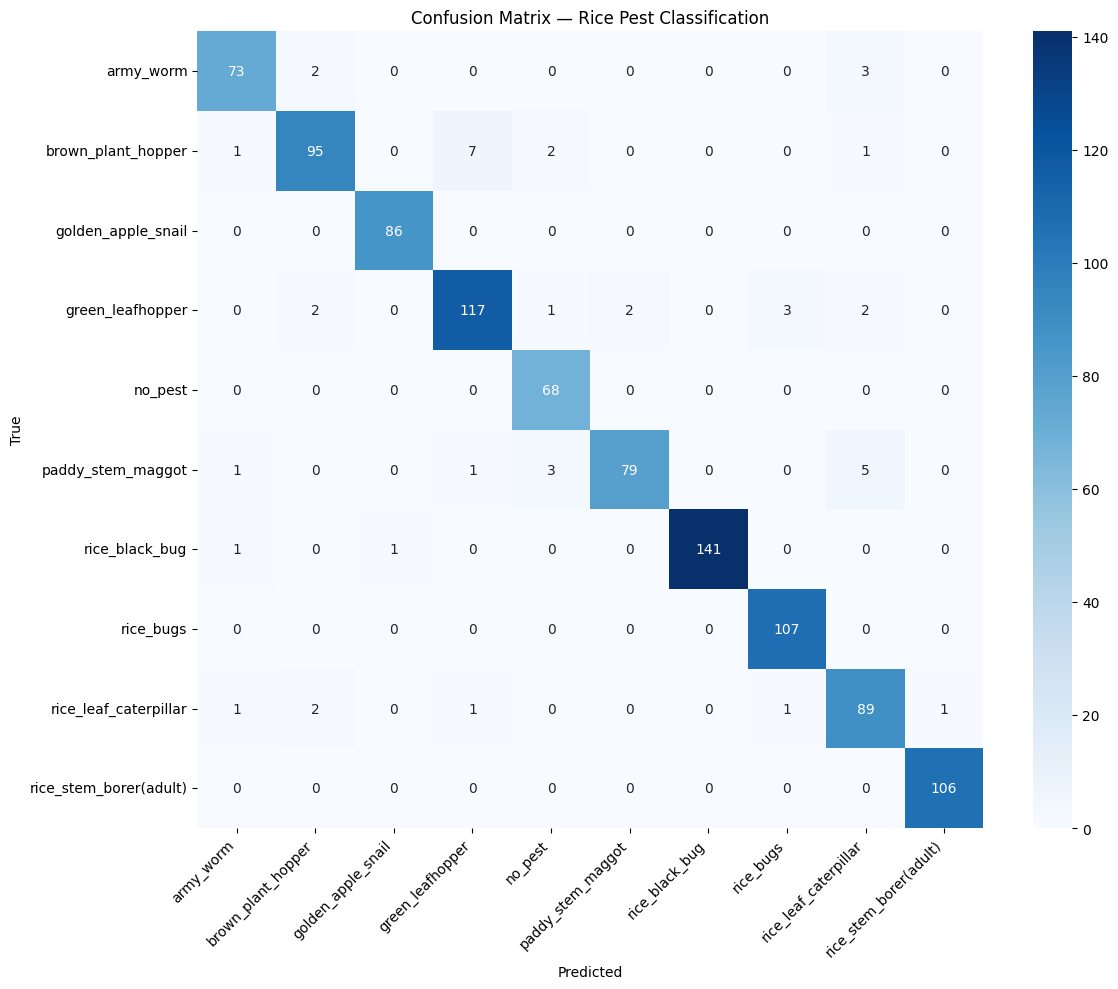


Per-class accuracy for the previously weak classes:
  golden_apple_snail: 100.0% (86 test images)


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix — Rice Pest Classification')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class accuracy for the previously weak classes:")
for cls in WEAK_CLASSES:
    idx = CLASS_NAMES.index(cls)
    cls_mask = all_labels == idx
    acc = (all_preds[cls_mask] == idx).mean() * 100 if cls_mask.sum() else float('nan')
    print(f"  {cls}: {acc:.1f}% ({cls_mask.sum()} test images)")

In [9]:
import pandas as pd
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score, balanced_accuracy_score,
    f1_score, cohen_kappa_score, matthews_corrcoef, top_k_accuracy_score,
    log_loss, confusion_matrix
)

# ---- Collect test probabilities ----
model.eval()
probs_list, labels_list = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        out = model(inputs.to(device))
        probs_list.append(F.softmax(out, dim=1).cpu().numpy())
        labels_list.append(labels.numpy())

probs  = np.concatenate(probs_list)
y_true = np.concatenate(labels_list)
y_pred = probs.argmax(1)
conf   = probs.max(1)
idx    = list(range(NUM_CLASSES))
cm     = confusion_matrix(y_true, y_pred, labels=idx)

# ---- Table 1: Overall metrics ----
overall = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced accuracy', 'Macro F1', 'Weighted F1',
               'Top-3 accuracy', "Cohen's kappa", 'MCC', 'Log loss'],
    'Value': [
        accuracy_score(y_true, y_pred),
        balanced_accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average='macro'),
        f1_score(y_true, y_pred, average='weighted'),
        top_k_accuracy_score(y_true, probs, k=min(3, NUM_CLASSES), labels=idx),
        cohen_kappa_score(y_true, y_pred),
        matthews_corrcoef(y_true, y_pred),
        log_loss(y_true, probs, labels=idx),
    ]
}).round(4)
print("TABLE 1: Overall metrics")
display(overall)

# ---- Table 2: Per-class metrics + most common mistake ----
p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=idx, zero_division=0)
off = cm.copy(); np.fill_diagonal(off, 0)
most_confused = [CLASS_NAMES[off[i].argmax()] if off[i].max() > 0 else '-' for i in idx]
confused_n    = [int(off[i].max()) for i in idx]
avg_conf      = [conf[y_true == i].mean() for i in idx]

per_class = pd.DataFrame({
    'Class': CLASS_NAMES, 'Precision': p, 'Recall': r, 'F1': f1, 'Support': sup,
    'Avg confidence': avg_conf,
    'Most confused with': most_confused, '# times': confused_n,
}).sort_values('F1').round(3).reset_index(drop=True)
print("\nTABLE 2: Per-class metrics (sorted worst to best F1)")
display(per_class)

# ---- Table 3: Top 10 confused class pairs ----
flat = [(CLASS_NAMES[i], CLASS_NAMES[j], int(off[i, j]))
        for i in idx for j in idx if off[i, j] > 0]
pairs = (pd.DataFrame(flat, columns=['True class', 'Predicted as', 'Count'])
           .sort_values('Count', ascending=False).head(10).reset_index(drop=True))
print("\nTABLE 3: Top confused pairs")
display(pairs)

# ---- Table 4: Confidence analysis (useful for a "not sure" threshold in the app) ----
correct = y_pred == y_true
rows = []
for t in [0.0, 0.5, 0.6, 0.7, 0.8, 0.9]:
    keep = conf >= t
    rows.append({
        'Min confidence': t,
        'Coverage (% of images answered)': 100 * keep.mean(),
        'Accuracy on answered (%)': 100 * correct[keep].mean() if keep.any() else np.nan,
    })
print("\nTABLE 4: Accuracy vs confidence threshold")
display(pd.DataFrame(rows).round(2))
print(f"Mean confidence when correct: {conf[correct].mean():.3f} | when wrong: {conf[~correct].mean():.3f}")

# ---- Save tables for your report ----
per_class.to_csv(f'{DRIVE_ROOT}/per_class_metrics.csv', index=False)
pairs.to_csv(f'{DRIVE_ROOT}/top_confused_pairs.csv', index=False)
overall.to_csv(f'{DRIVE_ROOT}/overall_metrics.csv', index=False)


TABLE 1: Overall metrics


,Metric,Value
0,Accuracy,0.9562
1,Balanced accuracy,0.9564
2,Macro F1,0.9549
3,Weighted F1,0.9560
4,Top-3 accuracy,0.9900
5,Cohen's kappa,0.9511
6,MCC,0.9512
7,Log loss,0.2603



TABLE 2: Per-class metrics (sorted worst to best F1)


,Class,Precision,Recall,F1,Support,Avg confidence,Most confused with,# times
0,rice_leaf_caterpillar,0.890,0.937,0.913,95,0.863,brown_plant_hopper,2
1,brown_plant_hopper,0.941,0.896,0.918,106,0.750,green_leafhopper,7
2,green_leafhopper,0.929,0.921,0.925,127,0.813,rice_bugs,3
3,paddy_stem_maggot,0.975,0.888,0.929,89,0.835,rice_leaf_caterpillar,5
4,army_worm,0.948,0.936,0.942,78,0.739,rice_leaf_caterpillar,3
5,no_pest,0.919,1.000,0.958,68,0.891,-,0
6,rice_bugs,0.964,1.000,0.982,107,0.871,-,0
7,rice_black_bug,1.000,0.986,0.993,143,0.868,army_worm,1
8,golden_apple_snail,0.989,1.000,0.994,86,0.915,-,0
9,rice_stem_borer(adult),0.991,1.000,0.995,106,0.887,-,0



TABLE 3: Top confused pairs


,True class,Predicted as,Count
0,brown_plant_hopper,green_leafhopper,7
1,paddy_stem_maggot,rice_leaf_caterpillar,5
2,green_leafhopper,rice_bugs,3
3,paddy_stem_maggot,no_pest,3
4,army_worm,rice_leaf_caterpillar,3
5,army_worm,brown_plant_hopper,2
6,green_leafhopper,rice_leaf_caterpillar,2
7,green_leafhopper,brown_plant_hopper,2
8,brown_plant_hopper,no_pest,2
9,green_leafhopper,paddy_stem_maggot,2



TABLE 4: Accuracy vs confidence threshold


,Min confidence,Coverage (% of images answered),Accuracy on answered (%)
0,0.0,100.00,95.62
1,0.5,93.53,98.30
2,0.6,90.85,98.90
3,0.7,86.47,99.31
4,0.8,81.19,99.51
5,0.9,49.45,99.80


Mean confidence when correct: 0.861 | when wrong: 0.457


In [10]:
!pip install onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 31.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.


In [11]:
!pip install onnx onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 17.2 MB/s eta 0:00:00


In [12]:
import torch.onnx, onnx, shutil

onnx_path = '/content/rice_pest_model.onnx'
dummy_input = torch.randn(1, 3, 224, 224).to(device)

model.eval()
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=13,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    dynamo=False,
)

onnx_model = onnx.load(onnx_path, load_external_data=False)
onnx.checker.check_model(onnx_model)
size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
print(f"File size: {size_mb:.1f} MB")
assert size_mb > 15, f"File suspiciously small ({size_mb:.1f} MB) — export likely broken, do not deploy"

shutil.copy(onnx_path, os.path.join(MODEL_DIR, 'rice_pest_model.onnx'))
torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES},
           os.path.join(MODEL_DIR, 'rice_pest_classifier_final.pth'))
print(f"✓ Saved rice_pest_model.onnx and rice_pest_classifier_final.pth to {MODEL_DIR}")

/tmp/ipykernel_2979/4280510712.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


File size: 16.1 MB
✓ Saved rice_pest_model.onnx and rice_pest_classifier_final.pth to /content/drive/MyDrive/rice-pest-cnn/model
